### Carregamento e criação de colunas

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Carregamento do dataset
file = 'AGO_ABR_transformed.csv'
file_path = os.path.join("NDT dataset", file)
df = pd.read_csv(file_path)

# Criar coluna de par cliente-servidor
df['client_server_pair'] = df['client_name'] + " -> " + df['server_name']

# Conversão de timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['data'] = df['timestamp'].dt.date

# Ordenar por tempo e par
df = df.sort_values(by=['client_server_pair', 'timestamp']).reset_index(drop=True)

# Criar coluna com a diferença de tempo
df['delta_tempo_horas'] = df.groupby('client_server_pair')['timestamp'].diff().dt.total_seconds() / 3600

### Filtragem

In [2]:
# manter apenas o tipo 'raspberry'
df_clean = df[df['tipo'] == 'raspberry'].copy()

# remover os valores nulos
df_clean = df_clean.dropna()

# remover os valores negativos
metricas = [
    'rtt_download', 'throughput_download', 
    'rtt_upload', 'throughput_upload', 'packet_loss'
]
for col in metricas:
    if col in df_clean.columns:
        df_clean = df_clean[df_clean[col] >= 0]

limite_horas = 12.0
seg_min = 1000
condicao_quebra = df_clean['delta_tempo_horas'] > limite_horas
df_clean['id_bloco'] = condicao_quebra.groupby(df_clean['client_server_pair']).cumsum()
df_clean['tamanho_bloco'] = df_clean.groupby(['client_server_pair', 'id_bloco'])['id_bloco'].transform('count')
df_clean = df_clean[df_clean['tamanho_bloco'] >= seg_min].copy()

### Contagem

Total de medições: 214615
Total de clientes distintos: 16
Total de servidores distintos: 6


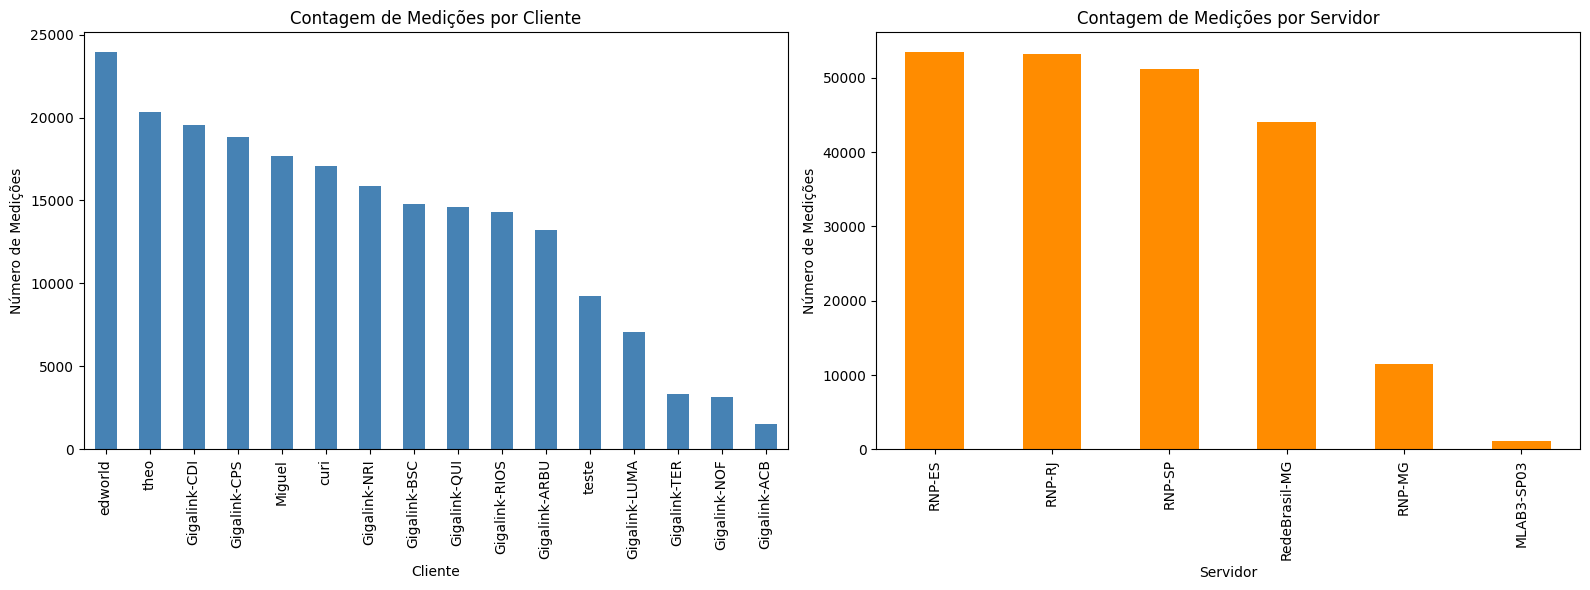

Total de pares cliente-servidor distintos: 59


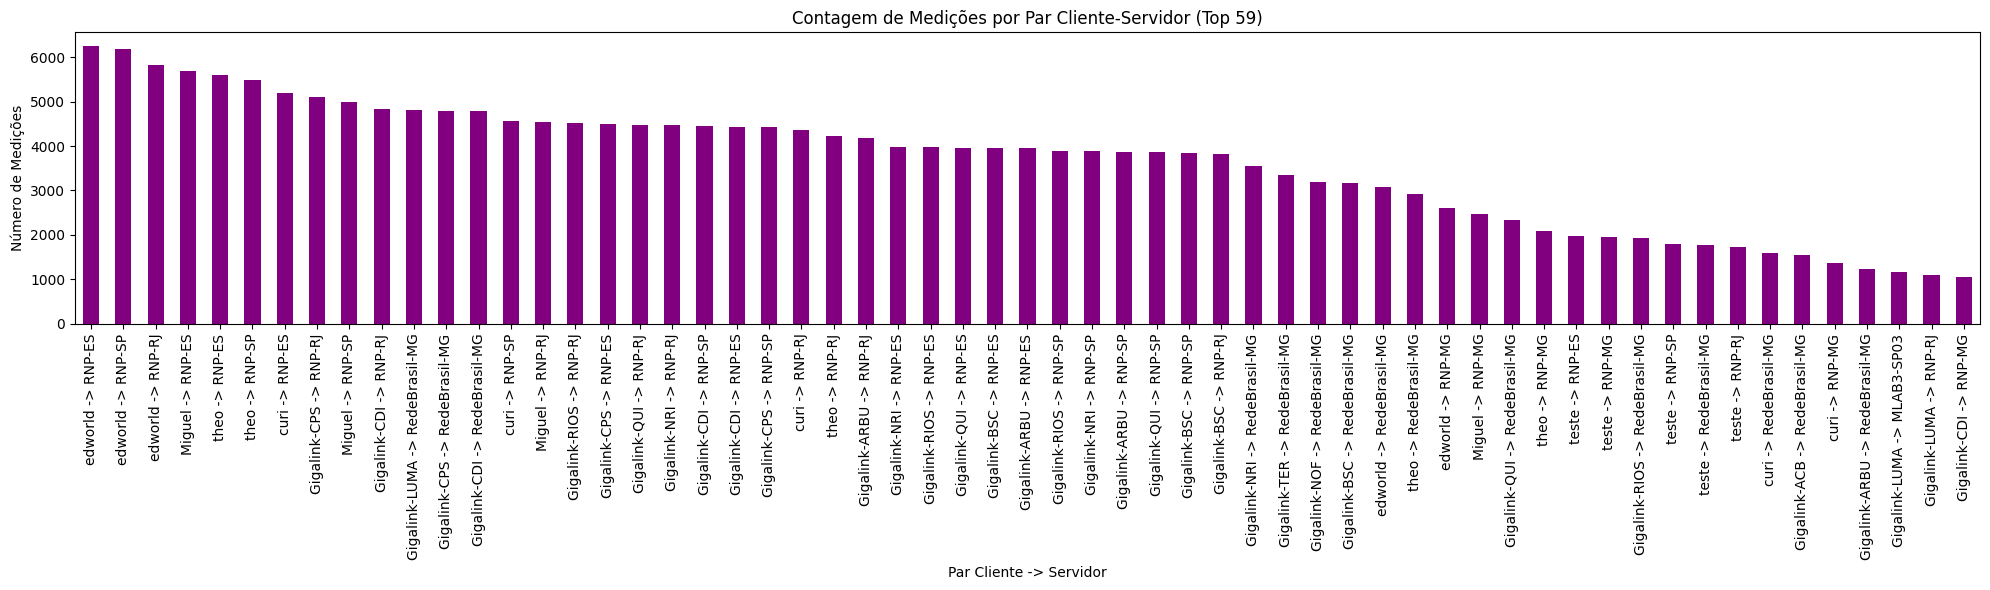

In [3]:
# Contagens Gerais
total_medicoes = len(df_clean)
num_clientes = df_clean['client_name'].nunique()
num_servidores = df_clean['server_name'].nunique()
num_pares = df_clean['client_server_pair'].nunique()

print(f"Total de medições: {total_medicoes}")
print(f"Total de clientes distintos: {num_clientes}")
print(f"Total de servidores distintos: {num_servidores}")

# Distribuição por Cliente e Servidor
medicoes_por_cliente = df_clean['client_name'].value_counts()
medicoes_por_servidor = df_clean['server_name'].value_counts()

# Plotagem em Gráficos de Barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Clientes
medicoes_por_cliente.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Contagem de Medições por Cliente')
axes[0].set_ylabel('Número de Medições')
axes[0].set_xlabel('Cliente')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de Servidores
medicoes_por_servidor.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Contagem de Medições por Servidor')
axes[1].set_ylabel('Número de Medições')
axes[1].set_xlabel('Servidor')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

num_pares = df_clean['client_server_pair'].nunique()
print(f"Total de pares cliente-servidor distintos: {num_pares}")

medicoes_por_par = df_clean['client_server_pair'].value_counts()

# filtrar pelos 30 pares mais comuns
medicoes_por_par = medicoes_por_par.head(100)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
medicoes_por_par.plot(kind='bar', color='purple')
plt.title(f'Contagem de Medições por Par Cliente-Servidor (Top {len(medicoes_por_par)})')
plt.xlabel('Par Cliente -> Servidor')
plt.ylabel('Número de Medições')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Plot dos gaps

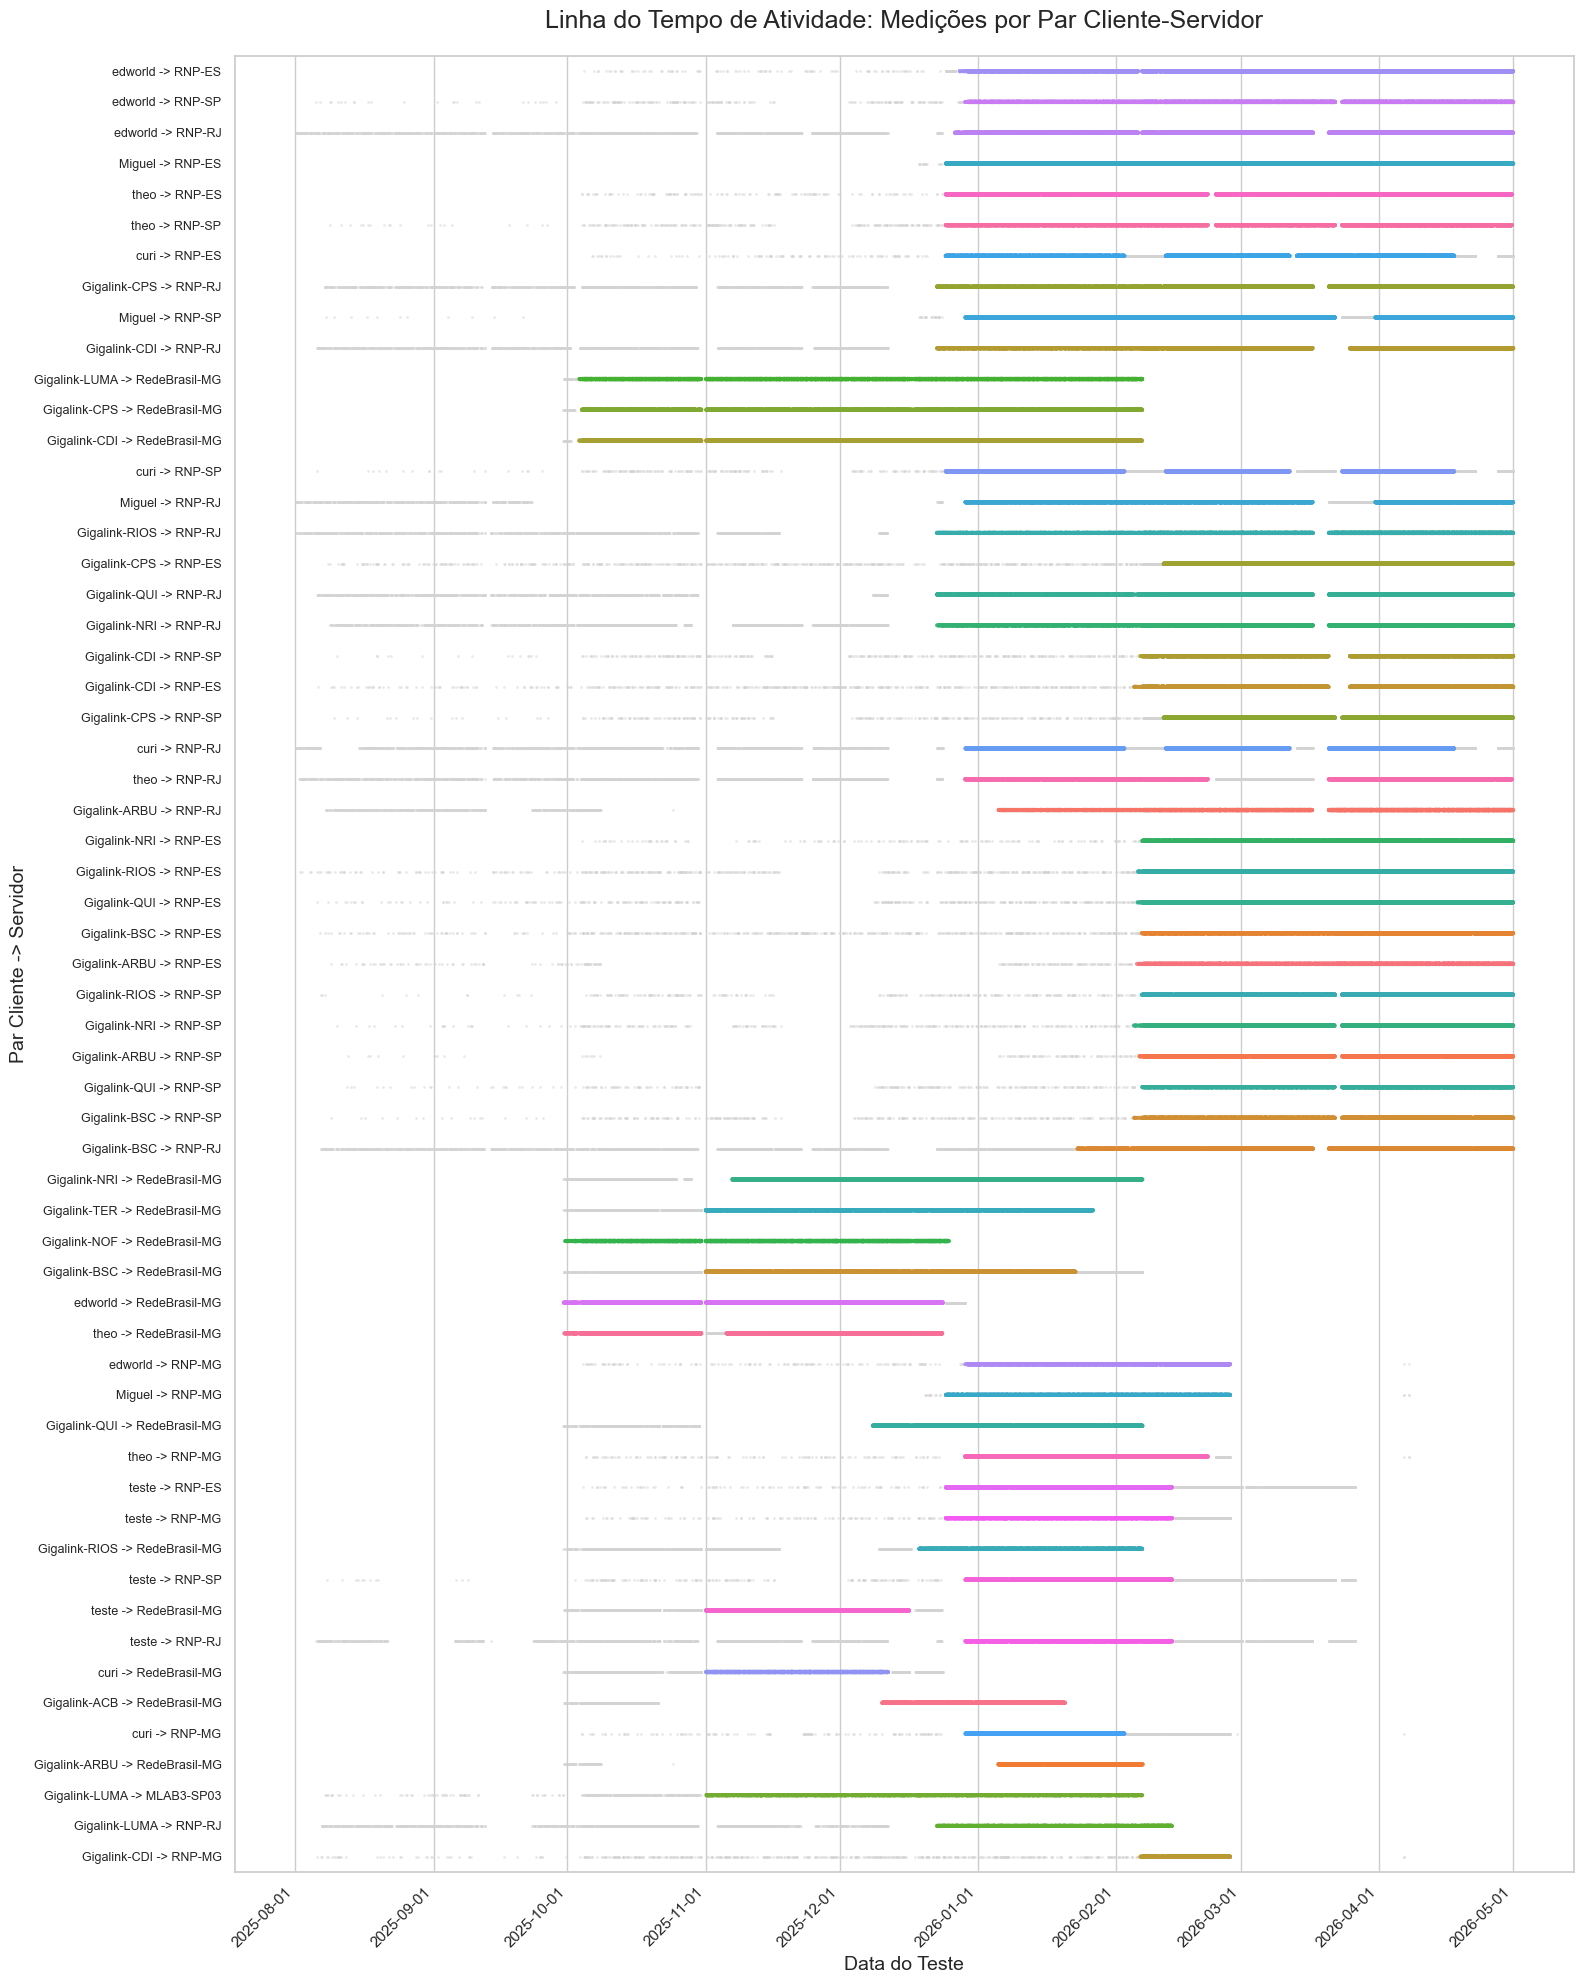

In [4]:
# 1. Cria a lista com os PARES ordenados pelo volume de uso
ordem_pares = df_clean['client_server_pair'].value_counts().index

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 20)) # Aumentei a altura para acomodar os pares

# 2. Usando STRIPPLOT por Par
sns.stripplot(
    data=df,
    x='timestamp', 
    y='client_server_pair',
    color='lightgray',
    size=2,
    alpha=0.5,
    order=ordem_pares,
    jitter=False,
    zorder=1
)
sns.stripplot(
    data=df_clean,
    x='timestamp', 
    y='client_server_pair',
    hue='client_server_pair',
    palette="husl",
    size=3,
    alpha=0.8,
    legend=False,
    order=ordem_pares,
    jitter=False,
    zorder=2
)

plt.title('Linha do Tempo de Atividade: Medições por Par Cliente-Servidor', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

# Formatação do eixo X (Tempo)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=9) # Fonte menor para os nomes dos pares

plt.tight_layout()
plt.show()

### Investigação de um par cliente-servidor

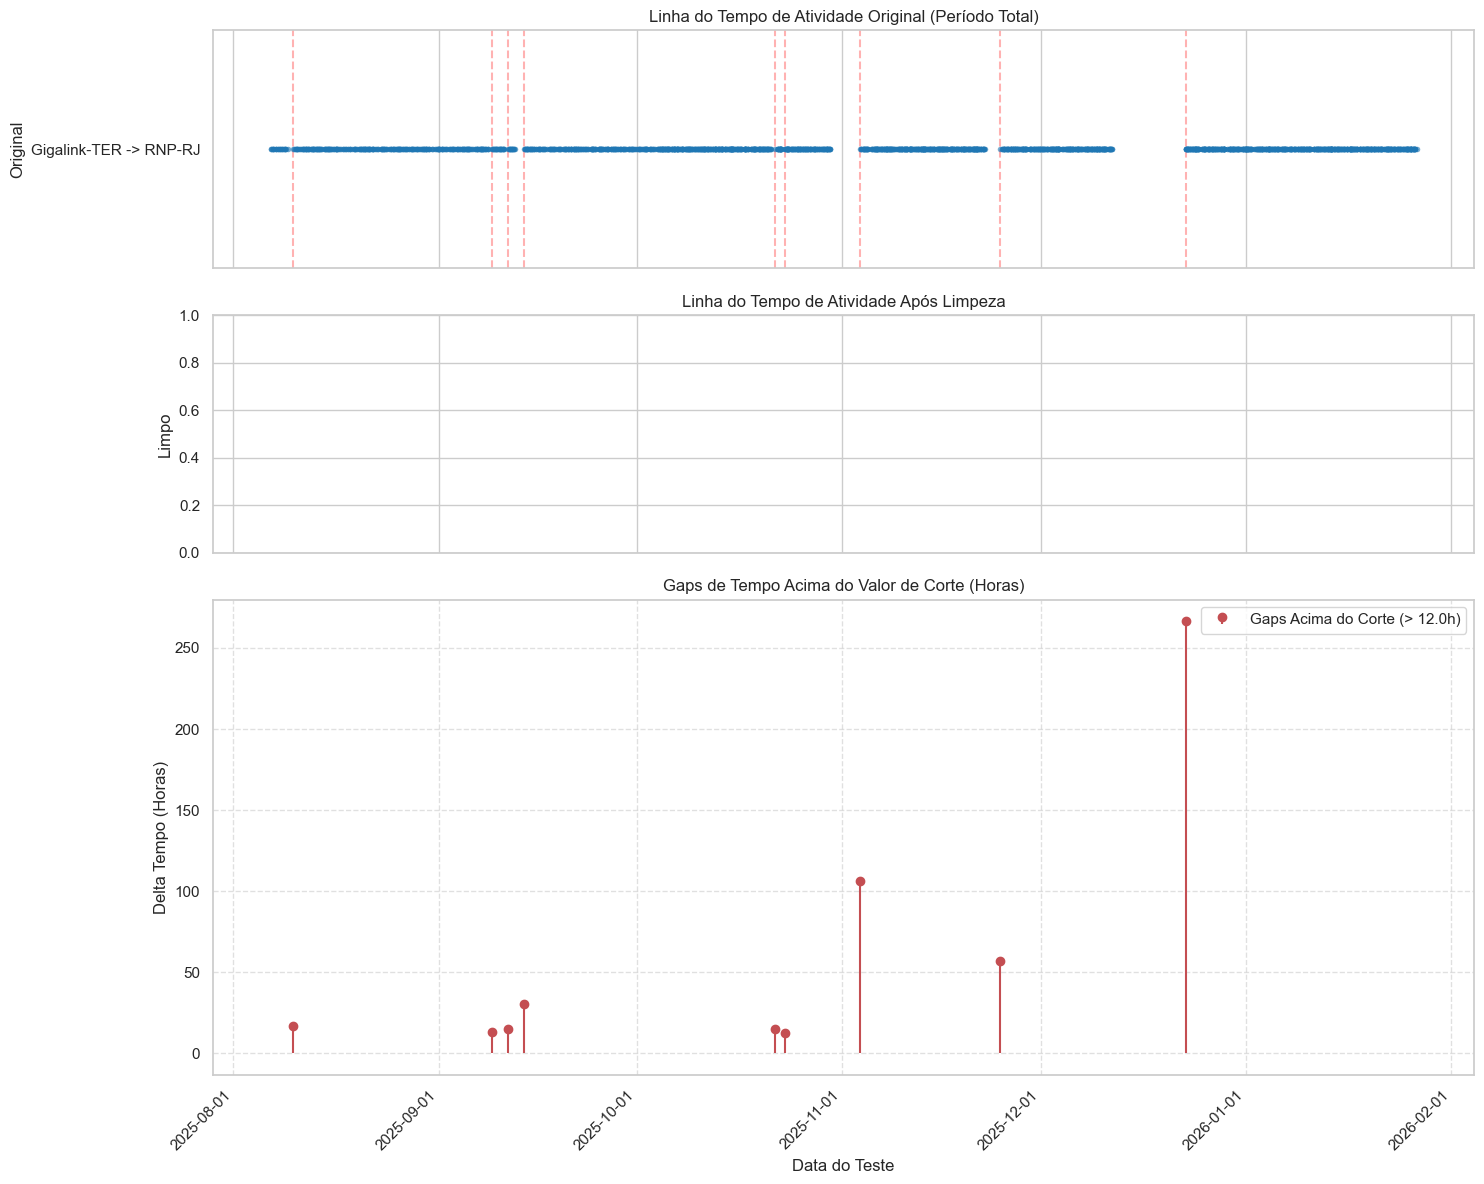

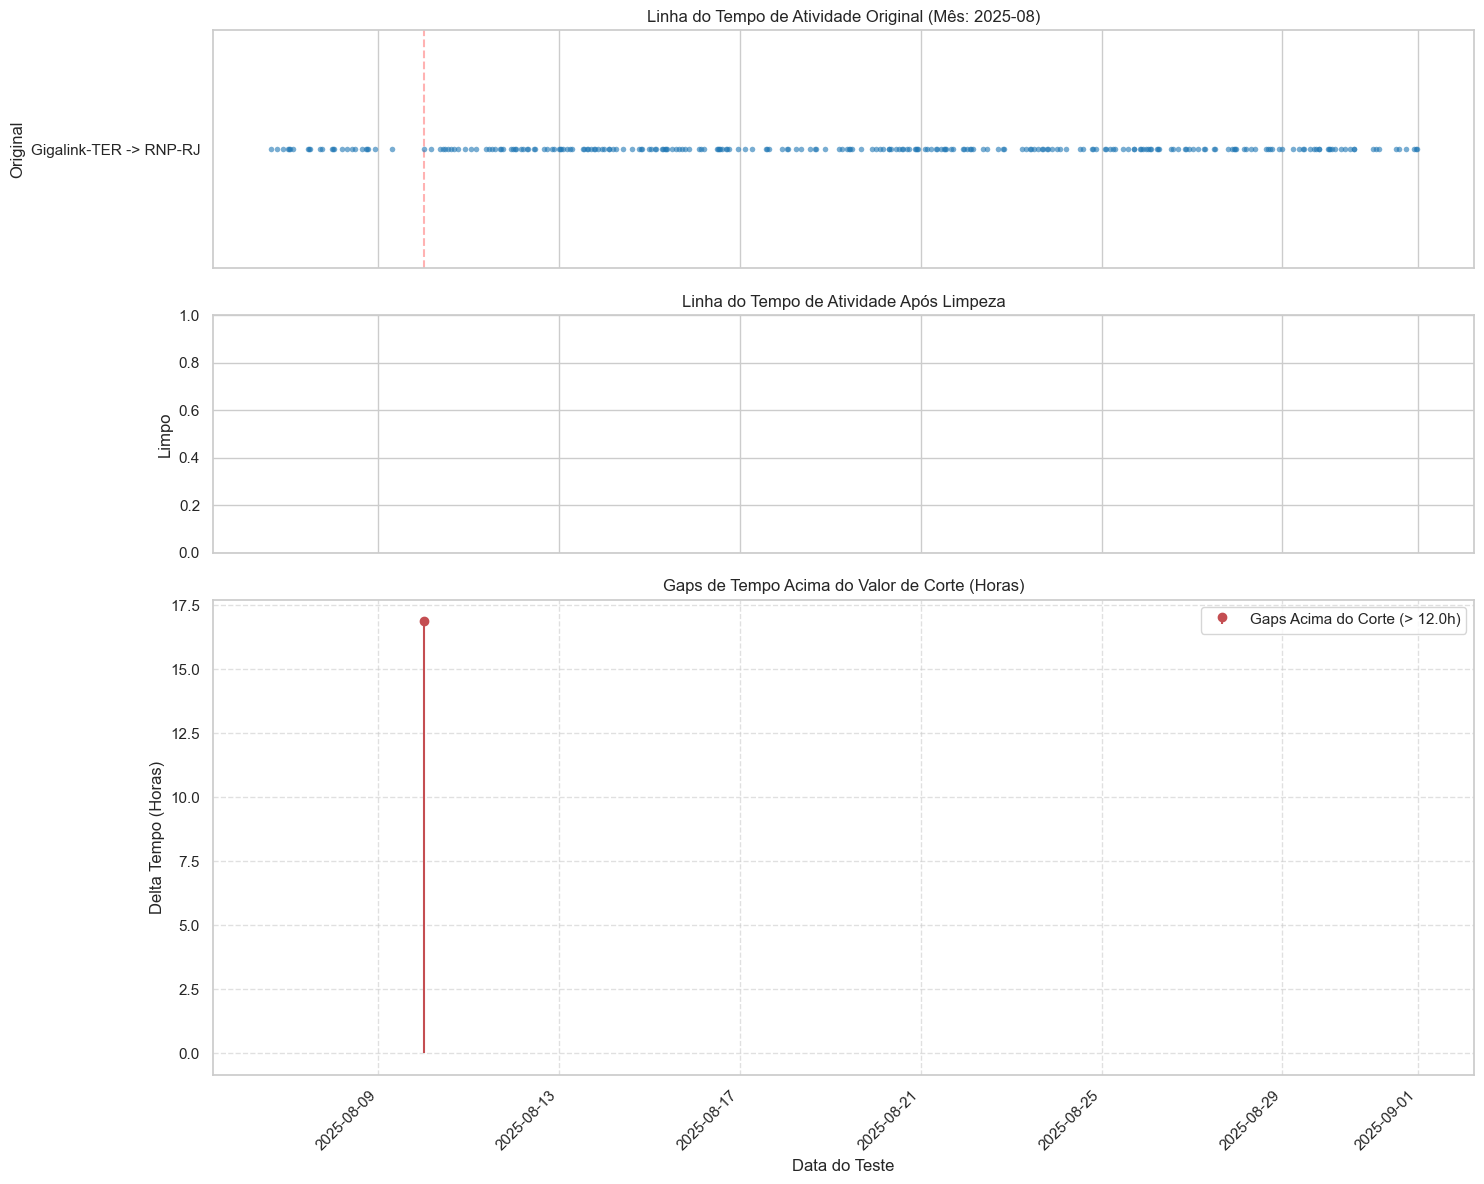

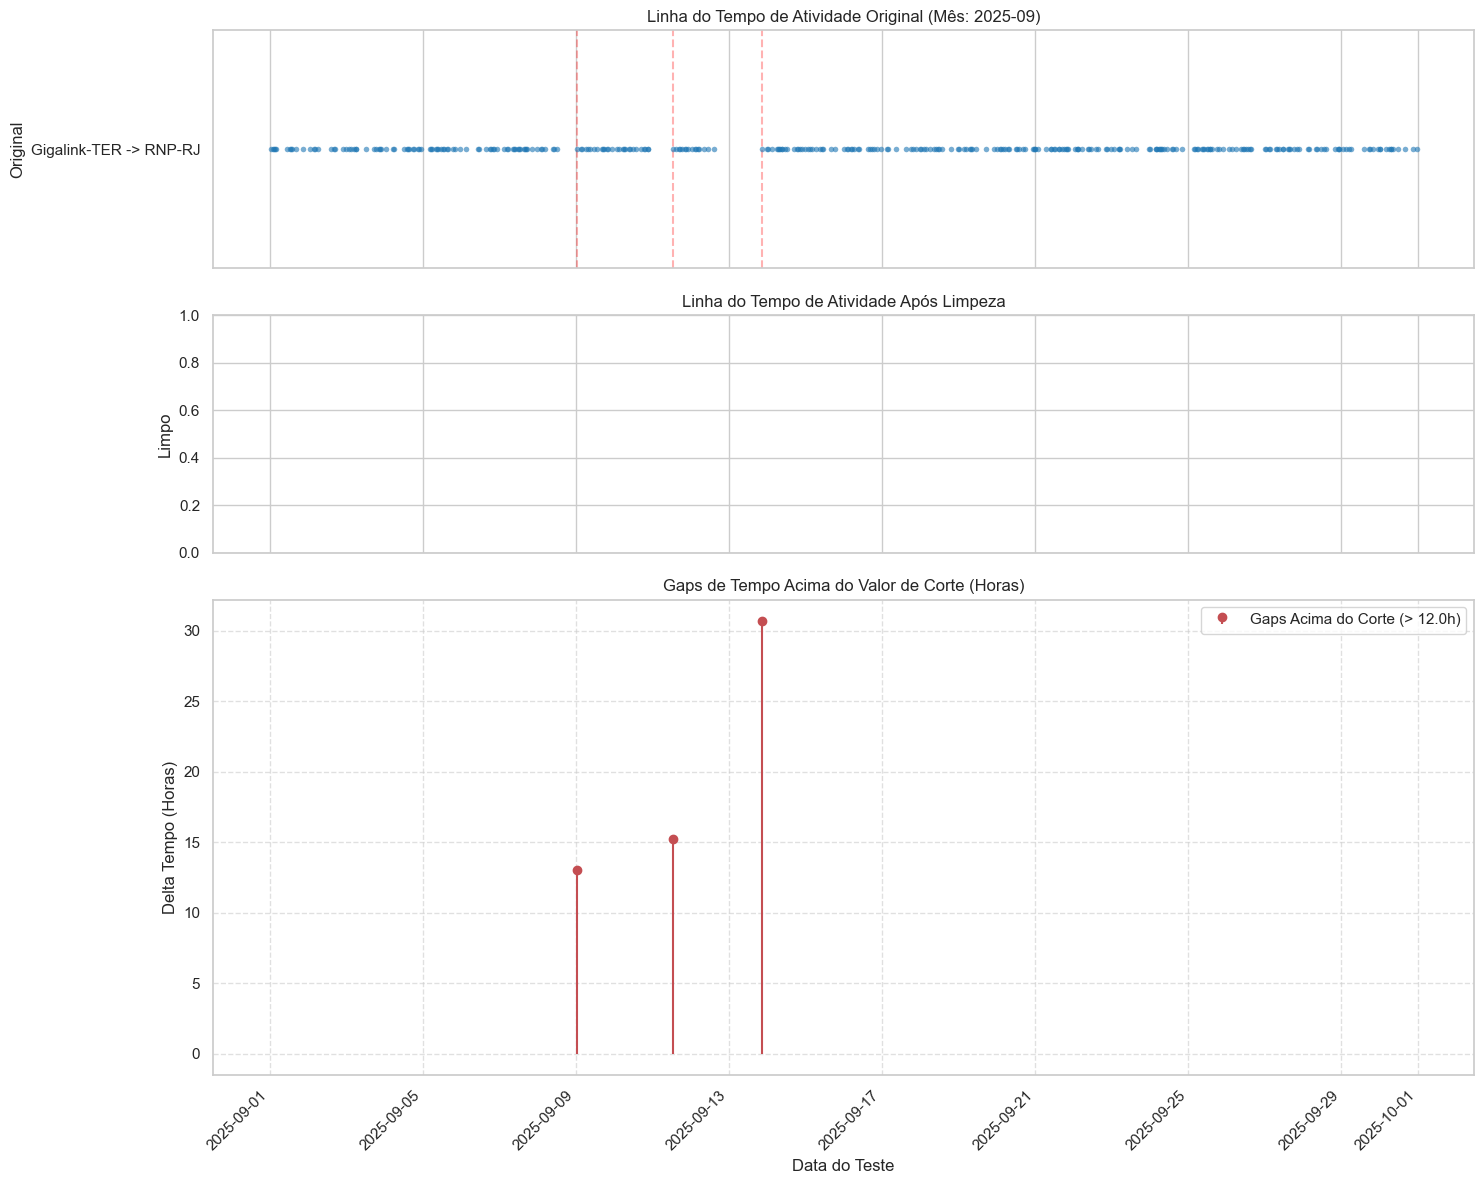

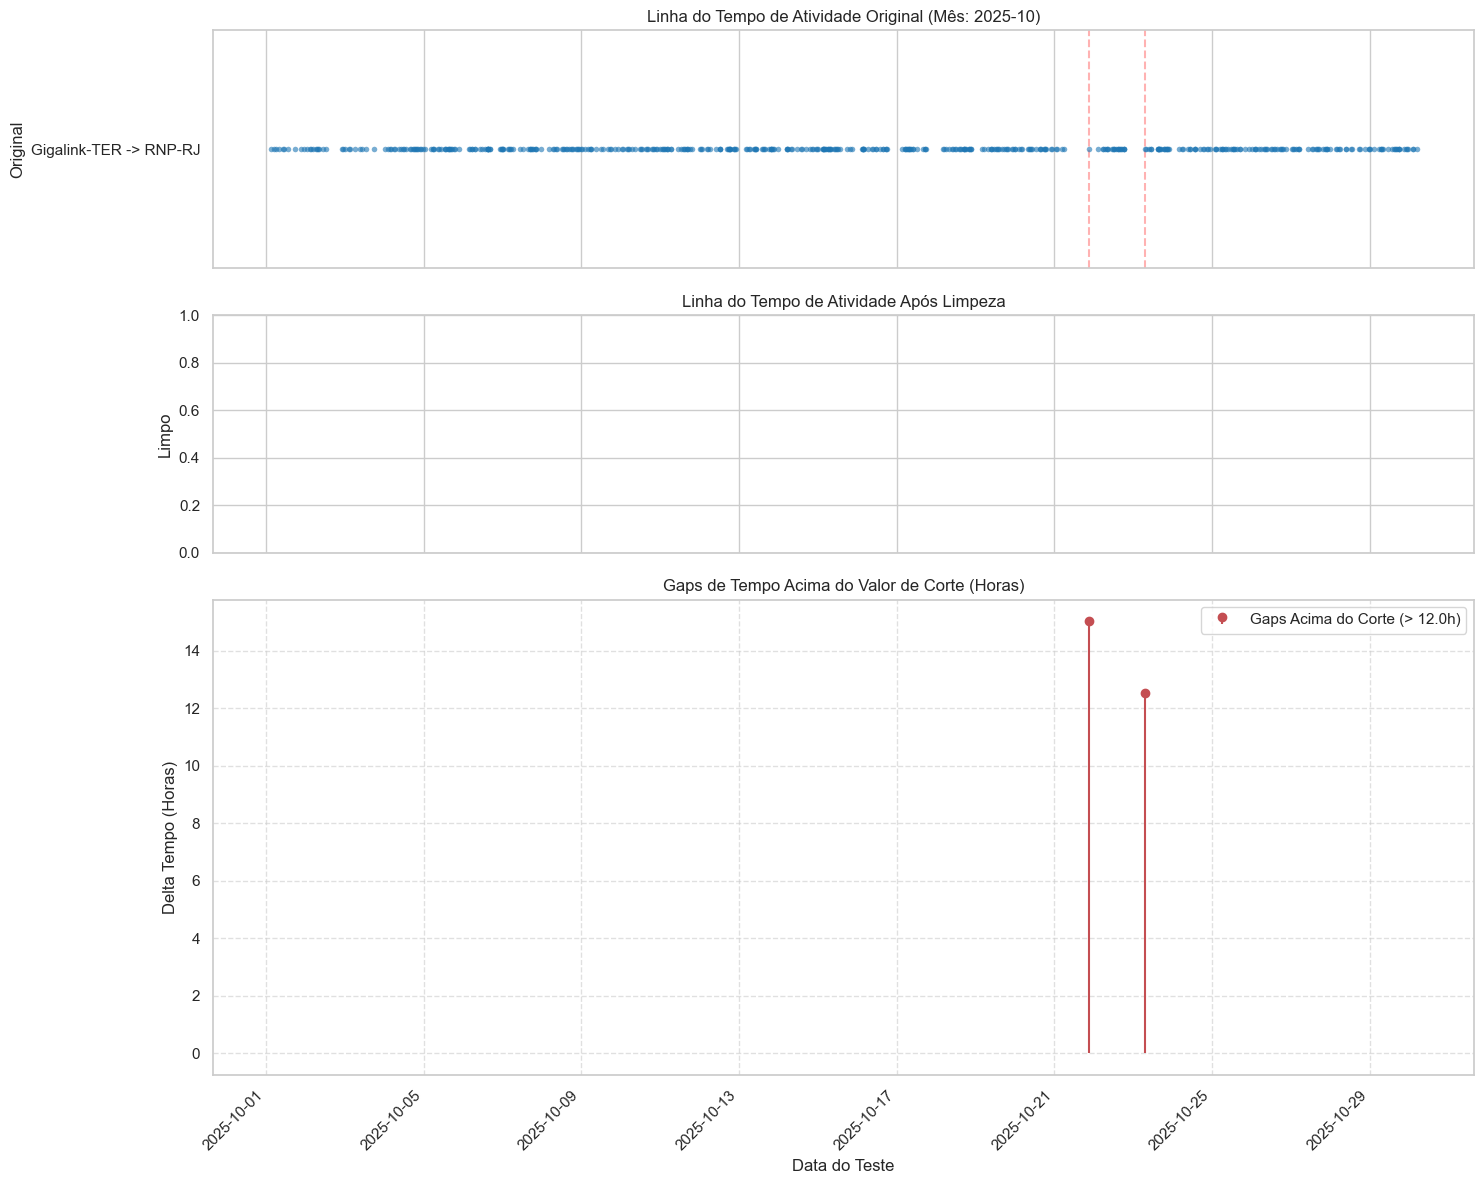

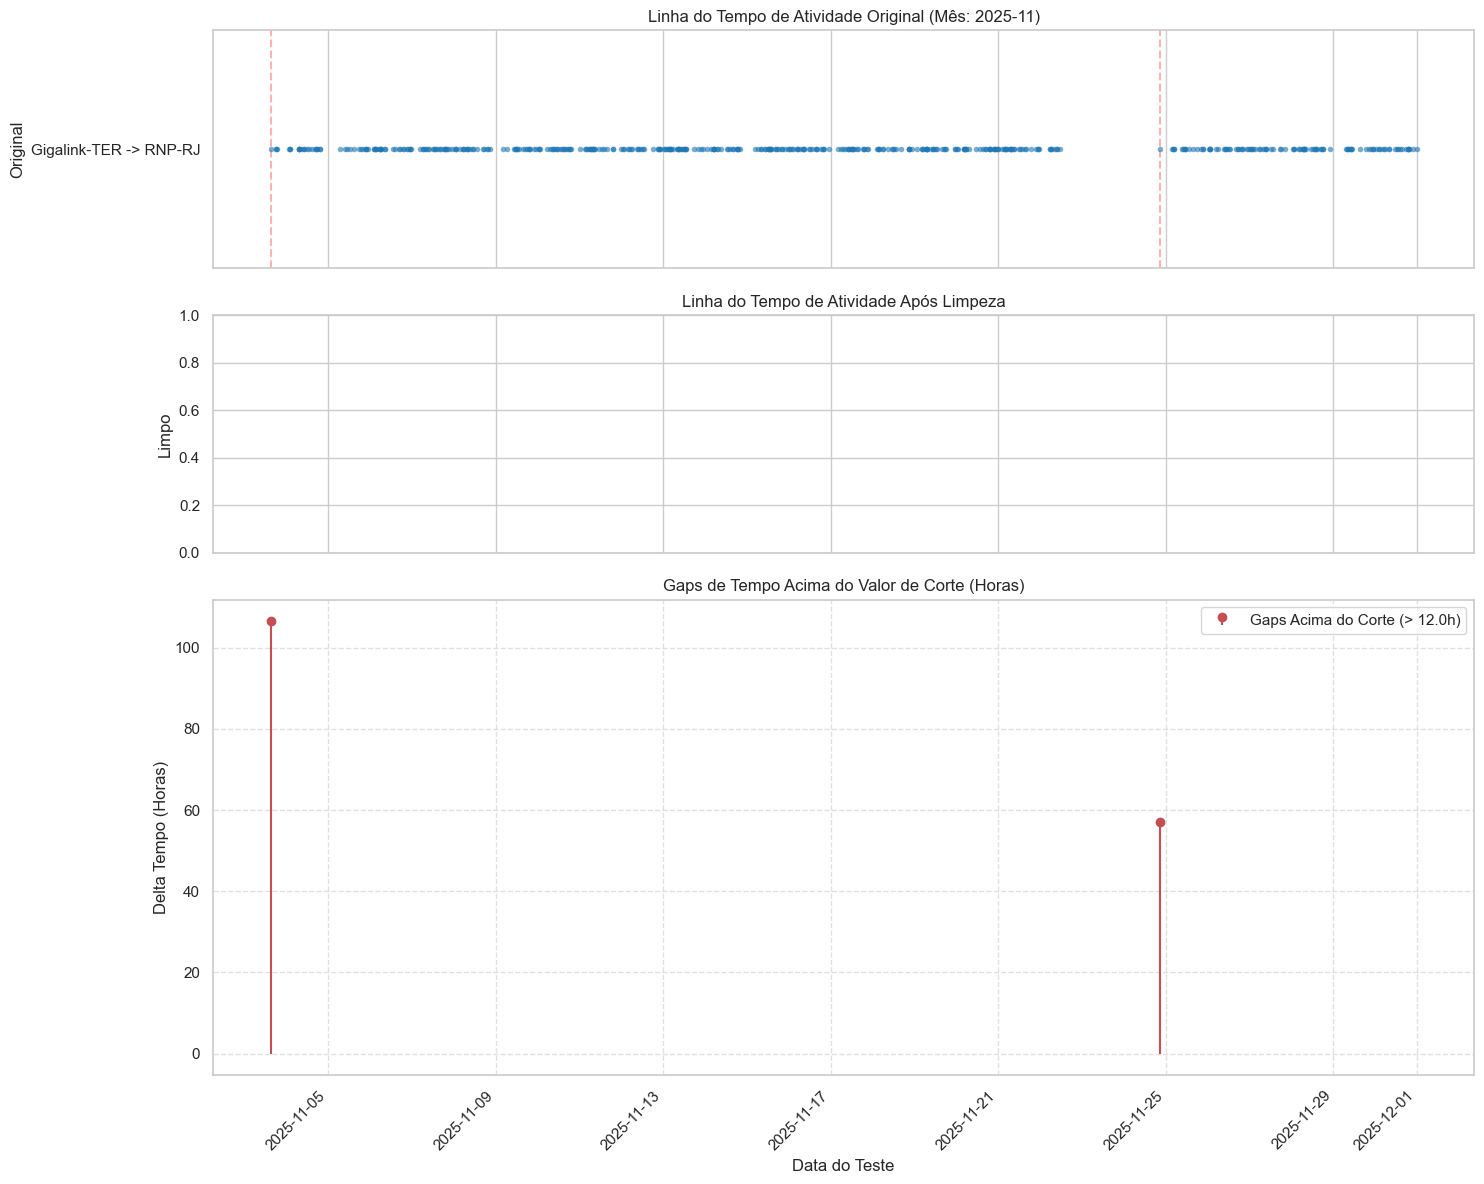

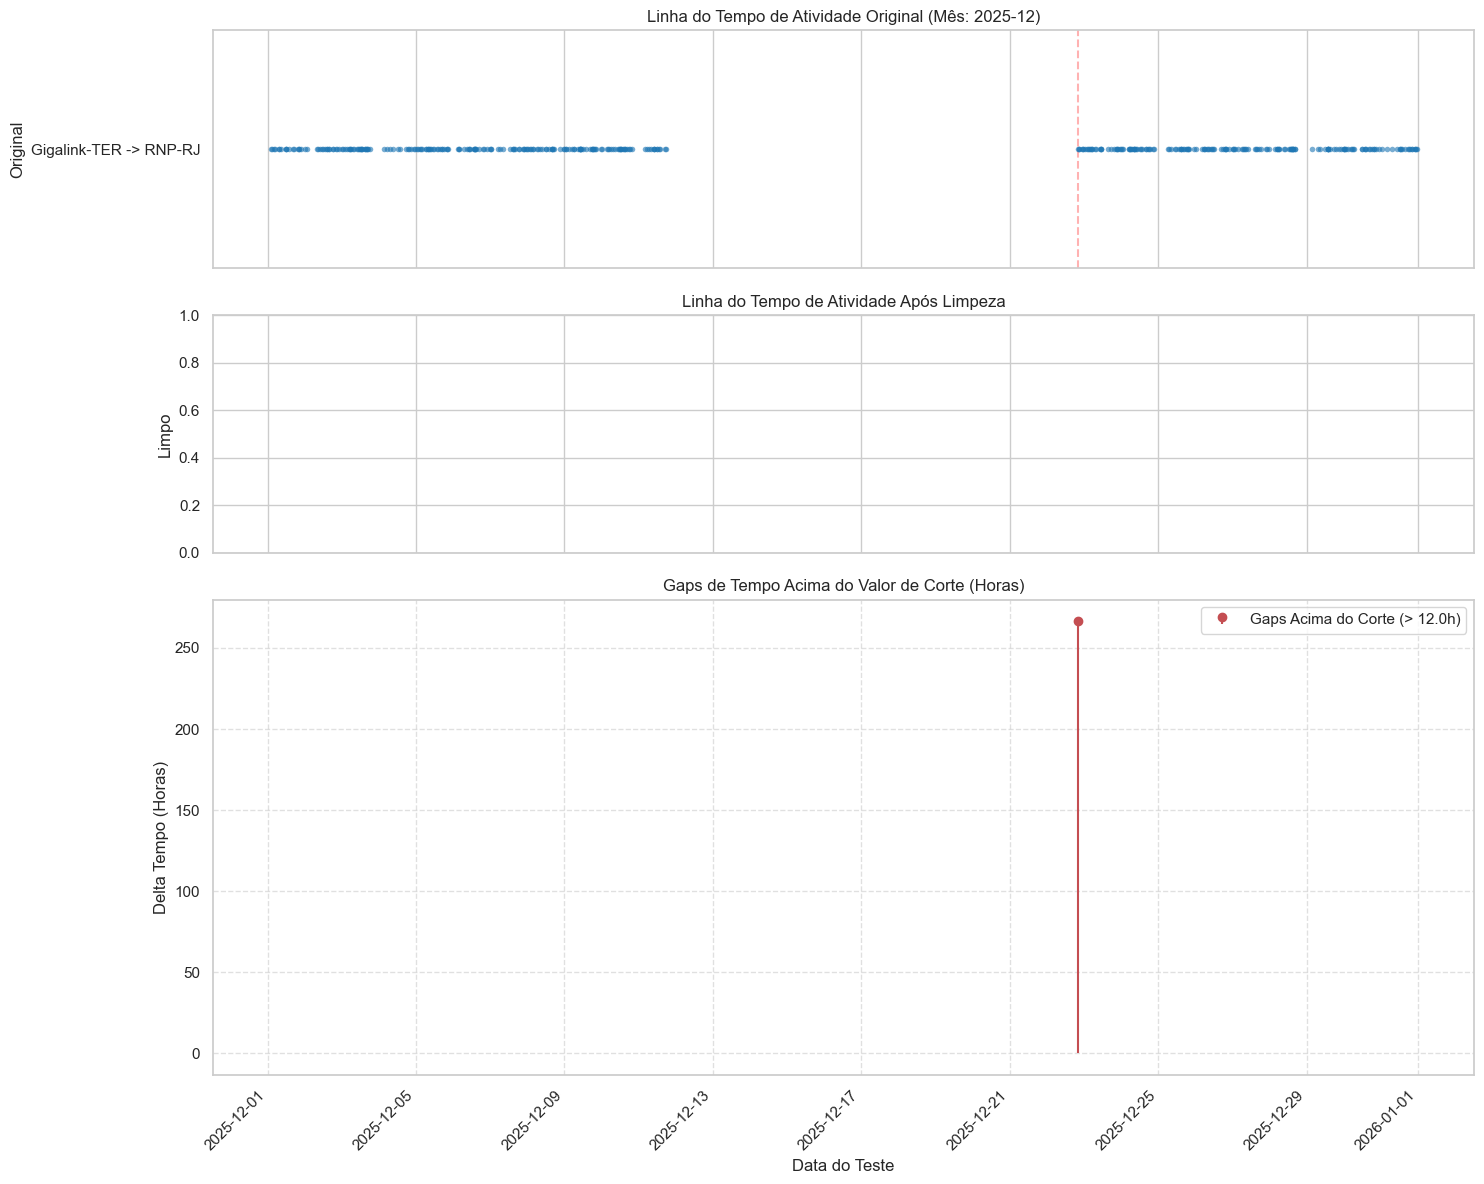

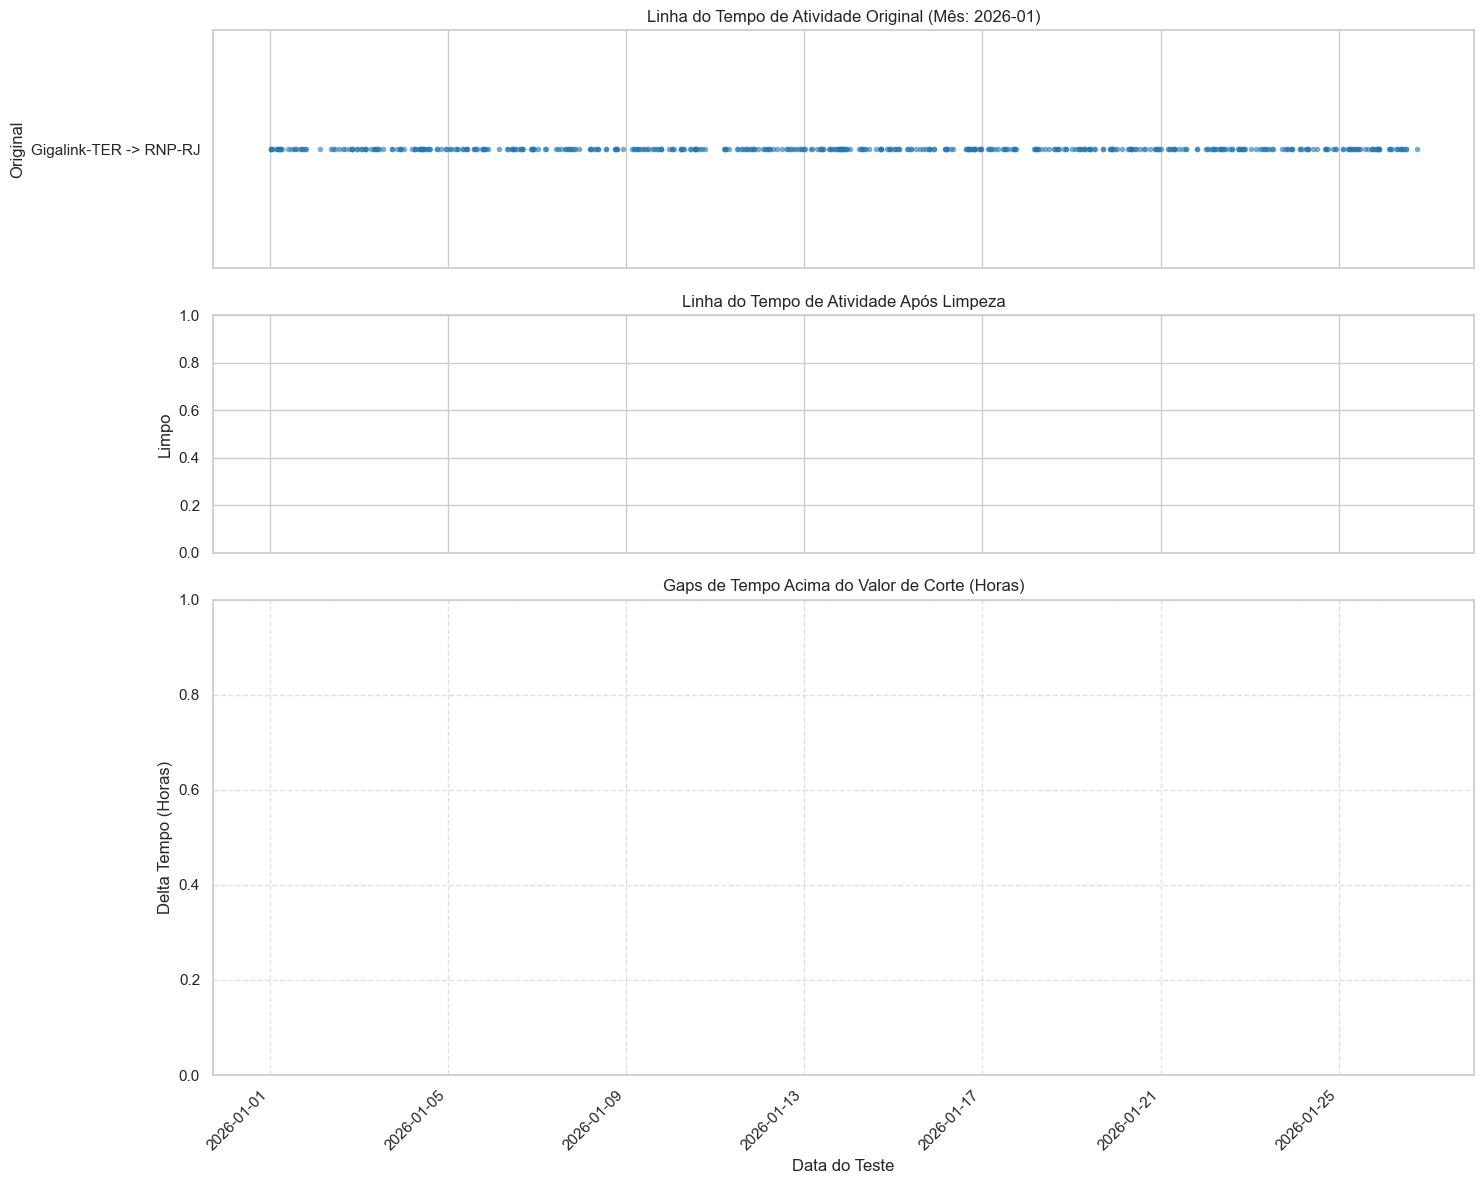

In [5]:
par_escolhido = df_clean['client_server_pair'].unique()[9]
par_escolhido = 'Gigalink-TER -> RNP-RJ'
df_par = df[df['client_server_pair'] == par_escolhido].copy()
df_limpo = df_clean[df_clean['client_server_pair'] == par_escolhido].copy()

def plot_comparacao_e_gaps(df_original, df_filtrado, titulo_periodo, limite_horas=12.0):
    gaps_acima_corte = df_original[df_original['delta_tempo_horas'] > limite_horas]
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 2]})
    
    sns.stripplot(
        data=df_original,
        x='timestamp',
        y='client_server_pair',
        color='#1f77b4',
        size=4,
        alpha=0.6,
        jitter=False,
        ax=ax1
    )
    ax1.set_title(f"Linha do Tempo de Atividade Original ({titulo_periodo})")
    ax1.set_ylabel("Original")
    ax1.set_xlabel("")
    
    for gap_time in gaps_acima_corte['timestamp']:
        ax1.axvline(x=gap_time, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
    
    sns.stripplot(
        data=df_filtrado,
        x='timestamp',
        y='client_server_pair',
        color='#1f77b4',
        size=4,
        alpha=0.6,
        jitter=False,
        ax=ax2
    )

    inicio_seguimento = df_filtrado[df_filtrado['delta_tempo_horas'] > limite_horas]
    for gap_time in inicio_seguimento['timestamp']:
        ax2.axvline(x=gap_time, color='red', linestyle='--', alpha=0.3, linewidth=1.5)

    ax2.set_title("Linha do Tempo de Atividade Após Limpeza")
    ax2.set_ylabel("Limpo")
    ax2.set_xlabel("")

    if not gaps_acima_corte.empty:
        ax3.stem(
            gaps_acima_corte['timestamp'], 
            gaps_acima_corte['delta_tempo_horas'], 
            linefmt='r-', 
            markerfmt='ro', 
            basefmt=' ', 
            label=f'Gaps Acima do Corte (> {limite_horas}h)'
        )
        ax3.legend()
    
    ax3.set_title("Gaps de Tempo Acima do Valor de Corte (Horas)")
    ax3.set_ylabel("Delta Tempo (Horas)")
    ax3.set_xlabel("Data do Teste")
    ax3.grid(True, linestyle='--', alpha=0.6)
    
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax3.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

plot_comparacao_e_gaps(df_par, df_limpo, "Período Total")

df_par['ano_mes'] = df_par['timestamp'].dt.tz_localize(None).dt.to_period('M')
df_limpo['ano_mes'] = df_limpo['timestamp'].dt.tz_localize(None).dt.to_period('M')
meses = df_par['ano_mes'].unique()

for mes in sorted(meses):
    df_mes_par = df_par[df_par['ano_mes'] == mes]
    df_mes_limpo = df_limpo[df_limpo['ano_mes'] == mes]
    if not df_mes_par.empty:
        plot_comparacao_e_gaps(df_mes_par, df_mes_limpo, f"Mês: {mes}")